# LoRA Fine-Tuning — DeBERTa-v3-large para NLI Jurídico 5 Clases

**Modelo base:** `cross-encoder/nli-deberta-v3-large` (~450M parámetros)

**Tarea:** Clasificación de 5 relaciones normativas:
- 0: CONTRADICCIÓN
- 1: COMPATIBILIDAD
- 2: ESPECIFICACIÓN
- 3: EXCEPCIÓN
- 4: NO_RELACIÓN

**Por qué LoRA y no full fine-tuning:**
Con 2500 muestras (500 por clase) y 450M parámetros, full fine-tuning
sobreajusta. LoRA entrena solo ~5-8M parámetros adicionales, preservando
el conocimiento del preentrenamiento y generalizando mejor con pocos datos.

In [1]:
# Verificar GPU
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# Instalar dependencias
!pip install transformers[torch] datasets peft scikit-learn \
             huggingface_hub accelerate -q
print("Instaladas")

✓ Instaladas


In [4]:
# Cargar y preparar dataset
import json, random
import numpy as np
from collections import Counter

DATASET_PATH = "dataset_5clases.json"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Mapeo de etiquetas
ID2LABEL = {
    0: "CONTRADICCION",
    1: "COMPATIBILIDAD",
    2: "ESPECIFICACION",
    3: "EXCEPCION",
    4: "NO_RELACION",
}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = 5

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)["dataset"]

# Normalizar estructura
datos = []
for item in raw:
    label = item.get("label")
    if isinstance(label, str):
        label = LABEL2ID.get(label.upper(), 4)
    datos.append({
        "text_a": item.get("text_a", "").strip(),
        "text_b": item.get("text_b", "").strip(),
        "label" : int(label),
    })

print(f"Total pares: {len(datos)}")
print("Distribución de clases:")
dist = Counter(d["label"] for d in datos)
for l, n in sorted(dist.items()):
    print(f"  {ID2LABEL[l]:>18}: {n}")

# Split estratificado 80/10/10
from sklearn.model_selection import train_test_split

labels_all = [d["label"] for d in datos]
train_data, temp = train_test_split(datos, test_size=0.20, stratify=labels_all, random_state=SEED)
labels_temp = [d["label"] for d in temp]
val_data, test_data = train_test_split(temp, test_size=0.50, stratify=labels_temp, random_state=SEED)

print(f"\nSplit: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

Total pares: 2500
Distribución de clases:
       CONTRADICCION: 500
      COMPATIBILIDAD: 500
      ESPECIFICACION: 500
           EXCEPCION: 500
         NO_RELACION: 500

Split: Train=2000, Val=250, Test=250


In [5]:
# Cargar tokenizer y tokenizar
from transformers import AutoTokenizer
from datasets import Dataset

# MODEL_BASE = "cross-encoder/nli-deberta-v3-large"
MODEL_BASE = "cross-encoder/nli-deberta-v3-base"
MAX_LENGTH = 512

print(f"Cargando tokenizer de {MODEL_BASE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)
print("✓ Tokenizer cargado")

def tokenizar(datos_lista, tokenizer, max_len=MAX_LENGTH):
    ds = Dataset.from_dict({
        "text_a": [d["text_a"] for d in datos_lista],
        "text_b": [d["text_b"] for d in datos_lista],
        "label" : [d["label"]  for d in datos_lista],
    })
    def tok(batch):
        return tokenizer(
            batch["text_a"], batch["text_b"],
            truncation=True, max_length=max_len, padding="max_length",
        )
    return ds.map(tok, batched=True, remove_columns=["text_a", "text_b"])

print("Tokenizando...")
train_ds = tokenizar(train_data, tokenizer)
val_ds   = tokenizar(val_data,   tokenizer)
test_ds  = tokenizar(test_data,  tokenizer)
print(f" Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}")

Cargando tokenizer de cross-encoder/nli-deberta-v3-base...


config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

✓ Tokenizer cargado
Tokenizando...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

✓ Train:2000 Val:250 Test:250


In [7]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [6]:
# Cargar modelo y aplicar LoRA
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

print(f"Cargando {MODEL_BASE} (~1.7GB, ~3 min)...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_BASE,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
print(f" Modelo cargado")

# Configuración LoRA
# DeBERTa-v3 usa atención disentangled con estos módulos clave:
# query_proj, key_proj, value_proj  → atención de contenido
# pos_query_proj, pos_key_proj      → atención posicional (específica de DeBERTa)
# Incluir todos da mejor cobertura sin aumentar demasiado los params

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,      # clasificación de secuencia
    r=16,                             # rango de las matrices LoRA
                                      # r=8: menos params, menos capacidad
                                      # r=16: buen balance para 2500 muestras
                                      # r=32: más capacidad, más riesgo overfitting
    lora_alpha=32,                    # escalado = alpha/r = 2.0
                                      # convención estándar: alpha = 2*r
    target_modules=[                  # módulos de atención de DeBERTa-v3
        "query_proj",
        "key_proj",
        "value_proj",
        "pos_query_proj",
        "pos_key_proj",
    ],
    lora_dropout=0.1,                 # regularización adicional
    bias="none",                      # no adaptar bias (más eficiente)
)

model = get_peft_model(model, lora_config)

# Verificar cuántos parámetros se entrenan
params_total      = sum(p.numel() for p in model.parameters())
params_trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros totales:     {params_total:>12,}")
print(f"Parámetros entrenables: {params_trainable:>12,} "
      f"({params_trainable/params_total*100:.2f}%)")
print(f"Parámetros congelados:  {params_total-params_trainable:>12,}")
print()
print("Interpretación:")
print(f"  LoRA entrena {params_trainable/1e6:.1f}M parámetros")
print(f"  vs Full FT: {params_total/1e6:.0f}M parámetros")
print(f"  Reducción: {(1-params_trainable/params_total)*100:.1f}% menos parámetros")

Cargando cross-encoder/nli-deberta-v3-base (~1.7GB, ~3 min)...


[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `3`.


model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([5])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✓ Modelo cargado

Parámetros totales:      185,314,570
Parámetros entrenables:      888,581 (0.48%)
Parámetros congelados:   184,425,989

Interpretación:
  LoRA entrena 0.9M parámetros
  vs Full FT: 185M parámetros
  Reducción: 99.5% menos parámetros


In [7]:
# Métricas
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    # F1 macro: trata todas las clases por igual
    # Importante para dataset balanceado (500 por clase)
    f1_macro  = f1_score(labels, preds, average="macro",  zero_division=0)
    f1_contra = f1_score(labels, preds, average=None,     zero_division=0)[0]  # clase 0
    acc       = accuracy_score(labels, preds)
    return {
        "f1_macro"       : round(f1_macro, 4),
        "f1_contradiccion": round(f1_contra, 4),  # la más importante para la tesis
        "accuracy"       : round(acc, 4),
    }

print(" Métricas definidas")
print("  Métrica principal: f1_macro (trata las 5 clases por igual)")
print("  Métrica secundaria: f1_contradiccion (clase 0, la que importa en la tesis)")

✓ Métricas definidas
  Métrica principal: f1_macro (trata las 5 clases por igual)
  Métrica secundaria: f1_contradiccion (clase 0, la que importa en la tesis)


In [8]:
# Configurar entrenamiento
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Con LoRA en T4, podemos usar batch más grande que full FT
BATCH_SIZE  = 16
EPOCHS      = 8
LR          = 2e-4   # LoRA usa LR más alto que full FT (2e-4 vs 2e-5)
                     # porque los parámetros LoRA se inicializan en 0
                     # y necesitan moverse más rápido

OUTPUT_DIR = "./deberta_lora_5clases"

pasos_por_epoca = len(train_ds) // BATCH_SIZE
tiempo_est = pasos_por_epoca * EPOCHS * 0.20 / 60
print(f"Pasos/época: {pasos_por_epoca}")
print(f"Tiempo estimado T4: {tiempo_est:.0f}-{tiempo_est*1.3:.0f} min")

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=20,
    report_to="none",
    seed=SEED,
    fp16=True,         # T4 soporta fp16
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
print("✓ Trainer configurado")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Pasos/época: 125
Tiempo estimado T4: 3-4 min
✓ Trainer configurado


In [10]:
# ENTRENAR
import time
print("Iniciando LoRA fine-tuning...")
t0 = time.time()
trainer.train()
print(f"\n Entrenamiento completado en {(time.time()-t0)/60:.1f} minutos")

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Iniciando LoRA fine-tuning...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Contradiccion,Accuracy
1,3.897355,0.725917,0.766800,0.888900,0.764000
2,2.352217,0.489273,0.812200,0.898000,0.816000
3,1.742086,0.478192,0.824300,0.930700,0.828000
4,1.403544,0.412311,0.851900,0.940000,0.852000
5,1.276386,0.411236,0.864100,0.949500,0.864000
6,0.929070,0.433919,0.855700,0.949500,0.856000
7,0.973349,0.460171,0.848400,0.949500,0.848000
8,0.898106,0.452325,0.861000,0.959200,0.860000



✓ Entrenamiento completado en 24.0 minutos


Evaluando sobre test set...


Training Loss,Validation Loss,Epoch,F1 Macro,F1 Contradiccion,Accuracy
0.898106,0.348101,8,0.856400,0.970900,0.860000



Resultados en test set:
  F1 macro:          0.8564
  F1 Contradicción:  0.9709
  Accuracy:          0.8600



Reporte por clase:
                precision    recall  f1-score   support

 CONTRADICCION       0.94      1.00      0.97        50
COMPATIBILIDAD       0.81      0.58      0.67        50
ESPECIFICACION       0.67      0.80      0.73        50
     EXCEPCION       0.96      0.92      0.94        50
   NO_RELACION       0.94      1.00      0.97        50

      accuracy                           0.86       250
     macro avg       0.86      0.86      0.86       250
  weighted avg       0.86      0.86      0.86       250



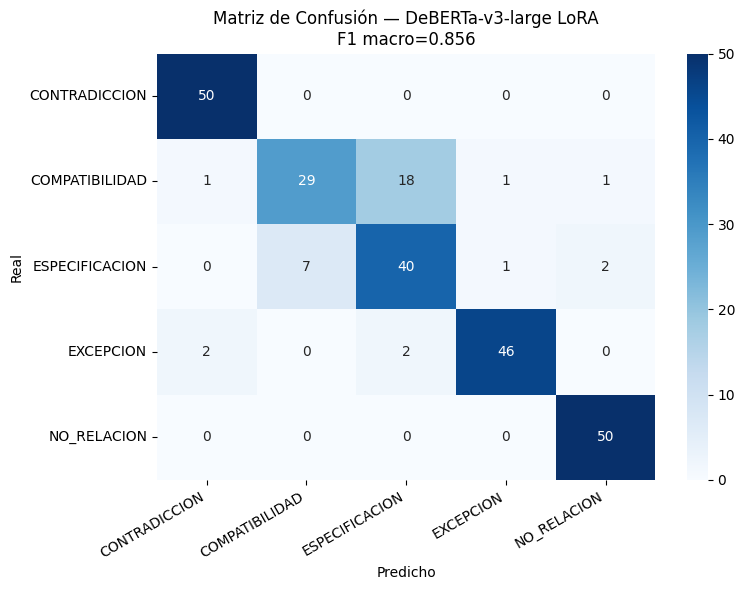

✓ Matriz guardada


In [11]:
# Evaluación final sobre test set
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluando sobre test set...")
test_results = trainer.evaluate(test_ds)
print(f"\nResultados en test set:")
print(f"  F1 macro:          {test_results['eval_f1_macro']:.4f}")
print(f"  F1 Contradicción:  {test_results['eval_f1_contradiccion']:.4f}")
print(f"  Accuracy:          {test_results['eval_accuracy']:.4f}")

# Predicciones para reporte detallado
pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

print("\nReporte por clase:")
print(classification_report(
    y_true, y_pred,
    target_names=list(ID2LABEL.values()),
    zero_division=0
))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=list(ID2LABEL.values()),
    yticklabels=list(ID2LABEL.values())
)
plt.title(f"Matriz de Confusión — DeBERTa-v3-large LoRA\nF1 macro={test_results['eval_f1_macro']:.3f}")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("matriz_confusion_5clases.png", dpi=150)
plt.show()
print("✓ Matriz guardada")

In [15]:
# Guardar y subir a HuggingFace
from peft import PeftModel
from huggingface_hub import login, HfApi
from google.colab import userdata

HF_TOKEN  = userdata.get("HF_TOKEN")
HF_REPO   = "sinai1carlos/deberta-lora-nli-juridico-peru-5clases"

# OPCIÓN A: Guardar solo los pesos LoRA (más pequeño, ~50MB)
# Ventaja: archivo pequeño, carga rápida
# Desventaja: necesitas el modelo base para inferencia
model.save_pretrained("./deberta_lora_pesos")
tokenizer.save_pretrained("./deberta_lora_pesos")
print("✓ Pesos LoRA guardados (ligeros)")

# OPCIÓN B: Mergear LoRA con el modelo base y guardar completo
# Ventaja: modelo standalone, fácil de usar en Docker/Jupyter
# Desventaja: archivo grande (~1.7GB)
print("Mergeando LoRA con modelo base...")
model_merged = model.merge_and_unload()  # fusiona LoRA en los pesos base
model_merged.save_pretrained("./deberta_lora_merged")
tokenizer.save_pretrained("./deberta_lora_merged")
print("✓ Modelo mergeado guardado (~1.7GB)")

# Guardar metadata importante
import json as json_mod
meta = {
    "modelo_base": MODEL_BASE,
    "lora_r": 16,
    "lora_alpha": 32,
    "num_labels": NUM_LABELS,
    "id2label": ID2LABEL,
    "f1_macro_test": test_results["eval_f1_macro"],
    "f1_contradiccion_test": test_results["eval_f1_contradiccion"],
    "accuracy_test": test_results["eval_accuracy"],
    "n_train": len(train_data),
    "params_entrenados": params_trainable,
}
with open("./deberta_lora_merged/metadata.json", "w") as f:
    json_mod.dump(meta, f, indent=2)

# Subir el modelo mergeado a HuggingFace
login(token=HF_TOKEN)
api = HfApi()
api.create_repo(repo_id=HF_REPO, exist_ok=True)
api.upload_folder(folder_path="./deberta_lora_merged", repo_id=HF_REPO)
print(f"\n✓ Modelo subido: https://huggingface.co/{HF_REPO}")

✓ Pesos LoRA guardados (ligeros)
Mergeando LoRA con modelo base...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Modelo mergeado guardado (~1.7GB)

✓ Modelo subido: https://huggingface.co/sinai1carlos/deberta-lora-nli-juridico-peru-5clases


In [17]:
# Verificar inferencia del modelo subido
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

print(f"Cargando modelo mergeado desde HuggingFace: {HF_REPO}")
tok_v = AutoTokenizer.from_pretrained(HF_REPO)
mod_v = AutoModelForSequenceClassification.from_pretrained(HF_REPO)
mod_v.eval()

ID2LABEL_V = mod_v.config.id2label
print(f"id2label: {ID2LABEL_V}")

def predecir_relacion(text_a, text_b):
    inputs = tok_v(
        text_a, text_b,
        return_tensors="pt", truncation=True,
        max_length=512, padding=True
    )
    with torch.no_grad():
        probs = torch.softmax(mod_v(**inputs).logits, dim=1)[0]
    idx_pred = probs.argmax().item()
    return {
        "etiqueta": ID2LABEL_V[idx_pred],
        "confianza": round(float(probs[idx_pred]), 4),
        "scores": {ID2LABEL_V[i]: round(float(probs[i]), 4) for i in range(len(probs))},
    }

# Tests con ejemplos de cada clase
tests = [
    ("El arrendatario debe usar el bien con diligencia ordinaria.",
     "El arrendatario puede subarrendar el bien sin restricción.",
     "CONTRADICCION"),
    ("El domicilio se constituye por residencia habitual.",
     "La persona que vive en varios lugares se considera domiciliada en cualquiera.",
     "COMPATIBILIDAD"),
    ("La persona humana es sujeto de derecho desde el nacimiento.",
     "El concebido es sujeto de derecho para todo cuanto le favorece.",
     "ESPECIFICACION"),
    ("Las partidas de inscripción prueban los hechos.",
     "Pueden hacerse rectificaciones en las partidas por resolución judicial.",
     "EXCEPCION"),
    ("La persona humana es sujeto de derecho desde el nacimiento.",
     "El interés moratorio se genera por el incumplimiento de una obligación.",
     "NO_RELACION"),
]

print("\nTests de verificación:")
correctos = 0
for ta, tb, esperado in tests:
    r = predecir_relacion(ta, tb)
    ok = "ok" if r["etiqueta"] == esperado else "fail"
    print(f"  {ok} Esperado={esperado:>15} | Predicho={r['etiqueta']:>15} (conf={r['confianza']:.3f})")
    if r["etiqueta"] == esperado:
        correctos += 1

print(f"\nAciertos verificación: {correctos}/5")
print(f"\n Modelo listo para usar en el notebook del ablation study")
print(f"  FINETUNED_MODEL = '{HF_REPO}'")

Cargando modelo mergeado desde HuggingFace: sinai1carlos/deberta-lora-nli-juridico-peru-5clases


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

id2label: {0: 'CONTRADICCION', 1: 'COMPATIBILIDAD', 2: 'ESPECIFICACION', 3: 'EXCEPCION', 4: 'NO_RELACION'}

Tests de verificación:
  ok Esperado=  CONTRADICCION | Predicho=  CONTRADICCION (conf=0.995)
  ok Esperado= COMPATIBILIDAD | Predicho= COMPATIBILIDAD (conf=0.444)
  ok Esperado= ESPECIFICACION | Predicho= ESPECIFICACION (conf=0.808)
  ok Esperado=      EXCEPCION | Predicho=      EXCEPCION (conf=0.961)
  ok Esperado=    NO_RELACION | Predicho=    NO_RELACION (conf=0.780)

Aciertos verificación: 5/5

 Modelo listo para usar en el notebook del ablation study
  FINETUNED_MODEL = 'sinai1carlos/deberta-lora-nli-juridico-peru-5clases'
